# 📝 Proyek UAS Deep Learning — Text Summarization Bahasa Indonesia

**Task E: Text Summarization**  
**Dataset:** `csebuetnlp/xlsum` (Indonesian) — 38.242 train, 4.780 test, 4.780 validation  
**Baseline:** TF-IDF Extractive Summarization  
**Model Fine-tuned:** `google/mt5-small`  
**Metrik Evaluasi:** ROUGE-1, ROUGE-2, ROUGE-L

---

**Alur Kerja:**
```
Data → Preprocessing → Baseline (TF-IDF) → Fine-tune mT5 → Evaluasi & Error Analysis → Demo
```

## 1. Setup & Konfigurasi

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import random
import warnings
import torch
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Cek GPU otomatis
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("WARNING: GPU tidak terdeteksi. Pastikan instalasi PyTorch CUDA sudah selesai.")


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB


In [14]:
# ========== KONFIGURASI ==========
# Parameter dikembalikan untuk penggunaan GPU

TRAIN_SUBSET = 3000       # Diubah ke 3.000 agar training lebih cepat
TEST_SUBSET = 1000        # Jumlah data test untuk evaluasi
BATCH_SIZE = 2            # Dinaikkan ke 2 untuk tes batas maksimal VRAM 6GB
GRAD_ACCUM = 8            # Effective batch size tetap 16 (2 x 8)
NUM_EPOCHS = 3            # Jumlah epoch training
LEARNING_RATE = 3e-4      # Learning rate
MAX_INPUT_LENGTH = 512    # Panjang maksimum input (token)
MAX_TARGET_LENGTH = 128   # Panjang maksimum target/ringkasan (token)
NUM_BEAMS = 4             # Beam search width untuk generasi
NUM_EXTRACT_SENTENCES = 3 # Jumlah kalimat yang diekstrak untuk baseline

MODEL_NAME = "google/mt5-small"
PREFIX = "summarize: "

print("Konfigurasi:")
print(f"  Train subset:    {TRAIN_SUBSET}")
print(f"  Test subset:     {TEST_SUBSET}")
print(f"  Batch size:      {BATCH_SIZE} (effective: {BATCH_SIZE * GRAD_ACCUM})")
print(f"  Epochs:          {NUM_EPOCHS}")
print(f"  Learning rate:   {LEARNING_RATE}")
print(f"  Model:           {MODEL_NAME}")


Konfigurasi:
  Train subset:    3000
  Test subset:     1000
  Batch size:      2 (effective: 16)
  Epochs:          3
  Learning rate:   0.0003
  Model:           google/mt5-small


## 2. Load & Eksplorasi Data

In [15]:
# Load dataset XLSum Indonesian
dataset = load_dataset("csebuetnlp/xlsum", "indonesian", trust_remote_code=True)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 38242
    })
    test: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 4780
    })
    validation: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 4780
    })
})


In [16]:
# Menampilkan fitur dataset
print("Fitur:", dataset["train"].features)
print()

# Menampilkan 3 contoh data
for i in range(3):
    sample = dataset["train"][i]
    print(f"--- Contoh {i+1} ---")
    print(f"Judul:     {sample['title']}")
    print(f"Artikel:   {sample['text'][:200]}...")
    print(f"Ringkasan: {sample['summary']}")
    print()

Fitur: {'id': Value(dtype='string', id=None), 'url': Value(dtype='string', id=None), 'title': Value(dtype='string', id=None), 'summary': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None)}

--- Contoh 1 ---
Judul:     Gajah mengamuk saat upacara keagamaan, 17 orang terluka
Artikel:   Dilaporkan dua orang terluka cukup serius, sementara sisanya sudah diperbolehkan pulang setelah mendapatkan perawatan. Video gajah yang mengamuk itu kontan viral di media sosial. Si gajah berlari tak ...
Ringkasan: Seekor gajah mendadak mengamuk saat prosesi tahunan agama Buddha di Kolombo, Sri Lanka, sehingga membuat peserta upacara tunggang-langgang. Setidaknya 17 orang terluka.

--- Contoh 2 ---
Judul:     Apa alasan pemerintah pangkas 14 dalam daftar Proyek Strategis Nasional ?
Artikel:   Proyek MRT Sudirman- Lebak Bulus tengah dikerjakan, namun untuk koridor Timur -Barat dicabut dari PSN. Pembangunan prasarana didengungkan sebagai ujung tombak pemerintahan Presiden Joko Widodo deng

  STATISTIK PANJANG TEKS (dalam kata)
                          Artikel    Ringkasan
-------------------- ------------ ------------
Mean                        423.5         22.2
Median                      266.0         21.0
Std                         402.2          6.7
Min                            23            0
Max                          8967          105

Rasio kompresi rata-rata: 0.083
(Ringkasan ~ 8.3% panjang artikel)


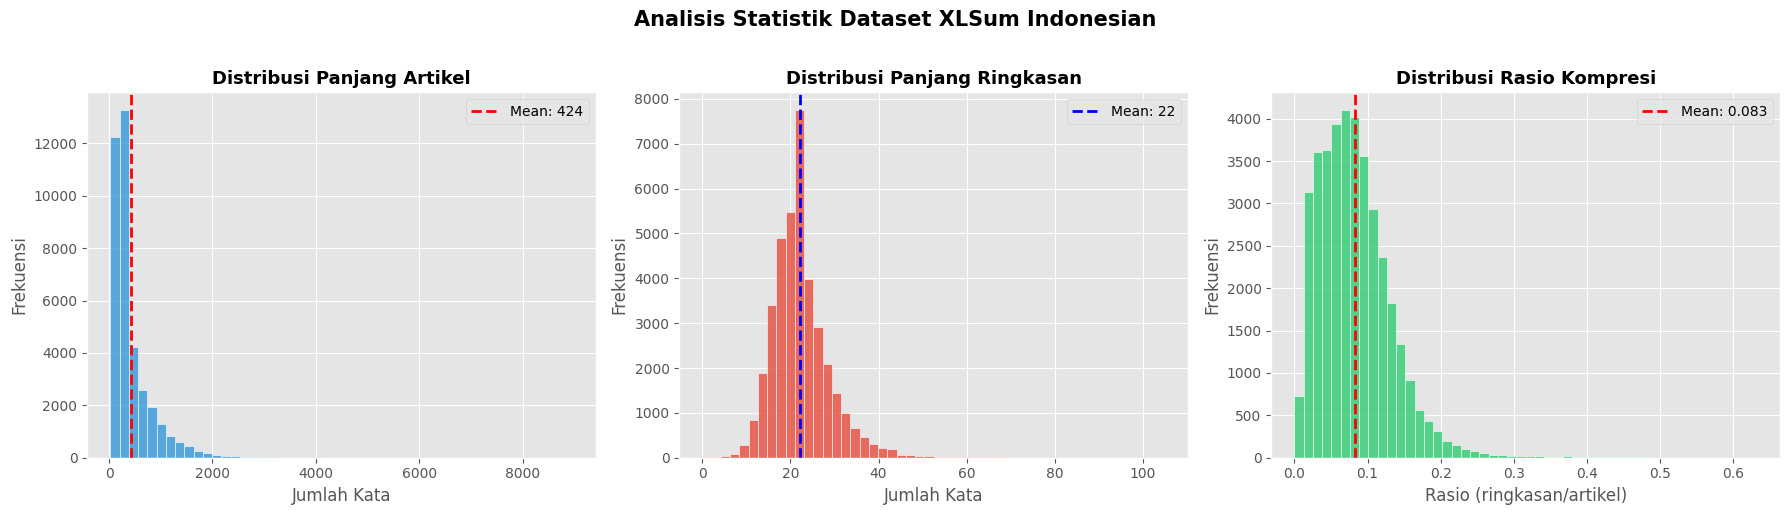

In [17]:
# Statistik panjang teks
train_data = dataset["train"]

article_lengths = [len(text.split()) for text in train_data["text"]]
summary_lengths = [len(text.split()) for text in train_data["summary"]]

print("=" * 55)
print("  STATISTIK PANJANG TEKS (dalam kata)")
print("=" * 55)
print(f"{'':20s} {'Artikel':>12s} {'Ringkasan':>12s}")
print(f"{'-'*20} {'-'*12} {'-'*12}")
print(f"{'Mean':20s} {np.mean(article_lengths):12.1f} {np.mean(summary_lengths):12.1f}")
print(f"{'Median':20s} {np.median(article_lengths):12.1f} {np.median(summary_lengths):12.1f}")
print(f"{'Std':20s} {np.std(article_lengths):12.1f} {np.std(summary_lengths):12.1f}")
print(f"{'Min':20s} {np.min(article_lengths):12d} {np.min(summary_lengths):12d}")
print(f"{'Max':20s} {np.max(article_lengths):12d} {np.max(summary_lengths):12d}")

# Rasio kompresi
compression = [s / max(a, 1) for s, a in zip(summary_lengths, article_lengths)]
print(f"\nRasio kompresi rata-rata: {np.mean(compression):.3f}")
print(f"(Ringkasan ~ {np.mean(compression)*100:.1f}% panjang artikel)")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(article_lengths, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(np.mean(article_lengths), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(article_lengths):.0f}')
axes[0].set_title('Distribusi Panjang Artikel', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

axes[1].hist(summary_lengths, bins=50, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].axvline(np.mean(summary_lengths), color='blue', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(summary_lengths):.0f}')
axes[1].set_title('Distribusi Panjang Ringkasan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

axes[2].hist(compression, bins=50, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[2].axvline(np.mean(compression), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(compression):.3f}')
axes[2].set_title('Distribusi Rasio Kompresi', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Rasio (ringkasan/artikel)')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.suptitle('Analisis Statistik Dataset XLSum Indonesian', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [18]:
def clean_text(text):
    """Membersihkan teks: hapus whitespace berlebih dan karakter kontrol."""
    # Hapus karakter kontrol
    text = re.sub(r'[\x00-\x08\x0b-\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    # Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Contoh preprocessing
print("Contoh preprocessing:")
print()
for i in range(2):
    original = dataset["train"][i]["text"]
    cleaned = clean_text(original)
    print(f"--- Contoh {i+1} ---")
    print(f"  Original ({len(original)} chars): {original[:150]}...")
    print(f"  Cleaned  ({len(cleaned)} chars):  {cleaned[:150]}...")
    print()

# Terapkan ke seluruh dataset
def preprocess_batch(examples):
    examples["text"] = [clean_text(t) for t in examples["text"]]
    examples["summary"] = [clean_text(s) for s in examples["summary"]]
    return examples

dataset = dataset.map(preprocess_batch, batched=True, desc="Preprocessing")
print("Preprocessing selesai untuk seluruh dataset!")

Contoh preprocessing:

--- Contoh 1 ---
  Original (697 chars): Dilaporkan dua orang terluka cukup serius, sementara sisanya sudah diperbolehkan pulang setelah mendapatkan perawatan. Video gajah yang mengamuk itu k...
  Cleaned  (697 chars):  Dilaporkan dua orang terluka cukup serius, sementara sisanya sudah diperbolehkan pulang setelah mendapatkan perawatan. Video gajah yang mengamuk itu k...

--- Contoh 2 ---
  Original (6663 chars): Proyek MRT Sudirman- Lebak Bulus tengah dikerjakan, namun untuk koridor Timur -Barat dicabut dari PSN. Pembangunan prasarana didengungkan sebagai ujun...
  Cleaned  (6663 chars):  Proyek MRT Sudirman- Lebak Bulus tengah dikerjakan, namun untuk koridor Timur -Barat dicabut dari PSN. Pembangunan prasarana didengungkan sebagai ujun...

Preprocessing selesai untuk seluruh dataset!


## 4. Baseline: TF-IDF Extractive Summarization

### Pendekatan Baseline

Untuk baseline, kita menggunakan **extractive summarization** berbasis TF-IDF:

1. **Pecah artikel** menjadi kalimat-kalimat individual
2. **Hitung TF-IDF** untuk setiap kalimat
3. **Hitung cosine similarity** setiap kalimat dengan representasi dokumen (rata-rata vektor)
4. **Ranking kalimat** berdasarkan skor similarity
5. **Pilih top-N kalimat** sebagai ringkasan (mempertahankan urutan asli)

> **Catatan:** Metode extractive hanya *memilih* kalimat dari teks asli, tidak menghasilkan kalimat baru.
> Ini berbeda dari abstractive summarization (mT5) yang menghasilkan kalimat baru.

In [19]:
def split_sentences_id(text):
    """Memecah teks Indonesia menjadi kalimat-kalimat."""
    # Split berdasarkan tanda baca akhir kalimat
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    # Filter kalimat yang terlalu pendek (noise)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 15]
    return sentences

def tfidf_extractive_summary(text, num_sentences=3):
    """
    Menghasilkan ringkasan ekstraktif menggunakan TF-IDF.

    Langkah:
    1. Pecah teks menjadi kalimat
    2. Hitung TF-IDF vektor untuk setiap kalimat
    3. Hitung cosine similarity terhadap representasi dokumen
    4. Pilih top-N kalimat dengan skor tertinggi (pertahankan urutan asli)
    """
    sentences = split_sentences_id(text)

    # Fallback jika kalimat terlalu sedikit
    if len(sentences) == 0:
        return text[:200]
    if len(sentences) <= num_sentences:
        return ' '.join(sentences)

    try:
        # Hitung TF-IDF
        vectorizer = TfidfVectorizer(max_features=5000)
        tfidf_matrix = vectorizer.fit_transform(sentences)

        # Representasi dokumen = rata-rata vektor semua kalimat
        doc_vector = tfidf_matrix.mean(axis=0)

        # Skor = cosine similarity kalimat vs dokumen
        scores = cosine_similarity(tfidf_matrix, doc_vector).flatten()

        # Pilih top-N kalimat, pertahankan urutan asli
        top_indices = np.argsort(scores)[-num_sentences:]
        top_indices = sorted(top_indices)

        summary = ' '.join([sentences[i] for i in top_indices])
        return summary
    except Exception:
        # Fallback: ambil kalimat pertama
        return ' '.join(sentences[:num_sentences])

# Test pada satu contoh
sample = dataset["test"][0]
print("ARTIKEL:")
print(sample["text"][:300] + "...")
print()
print("RINGKASAN REFERENSI:")
print(sample["summary"])
print()
print("RINGKASAN BASELINE (TF-IDF):")
print(tfidf_extractive_summary(sample["text"], num_sentences=NUM_EXTRACT_SENTENCES))

ARTIKEL:
Still Life, Vase with Daisies, and Poppies dibuat beberapa bulan sebelum van Gogh meninggal. Still Life, Vase with Daisies, and Poppies melampaui perkiraan sebelumnya US$50 juta pada pelelangan di Sotheby. Lukisan Van Gogh dibuat di rumah dokter Prancisnya hanya beberapa bulan sebelum dirinya mening...

RINGKASAN REFERENSI:
Sebuah mahakarya Vincent van Gogh, yang dilukis pada akhir kehidupannya, terjual di New York sebesar US$61,8 juta atau Rp752 miliar.

RINGKASAN BASELINE (TF-IDF):
Still Life, Vase with Daisies, and Poppies dibuat beberapa bulan sebelum van Gogh meninggal. Still Life, Vase with Daisies, and Poppies melampaui perkiraan sebelumnya US$50 juta pada pelelangan di Sotheby. Lukisan Van Gogh dibuat di rumah dokter Prancisnya hanya beberapa bulan sebelum dirinya meninggal di tahun 1890.


In [20]:
# Jalankan baseline pada test subset
print(f"Menjalankan TF-IDF baseline pada {TEST_SUBSET} data test...")
print()

test_data = dataset["test"].shuffle(seed=42).select(range(TEST_SUBSET))
test_articles = test_data["text"]
test_references = test_data["summary"]

# Generate ringkasan baseline
baseline_summaries = []
for i, article in enumerate(test_articles):
    summary = tfidf_extractive_summary(article, num_sentences=NUM_EXTRACT_SENTENCES)
    baseline_summaries.append(summary)
    if (i + 1) % 200 == 0:
        print(f"  Progress: {i+1}/{TEST_SUBSET}")

# Hitung ROUGE scores
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

baseline_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
for pred, ref in zip(baseline_summaries, test_references):
    score = rouge.score(ref, pred)
    for key in baseline_scores:
        baseline_scores[key].append(score[key].fmeasure * 100)

baseline_rouge = {key: np.mean(vals) for key, vals in baseline_scores.items()}

print()
print("=" * 50)
print("  HASIL BASELINE TF-IDF EXTRACTIVE")
print("=" * 50)
print(f"  ROUGE-1: {baseline_rouge['rouge1']:.2f}")
print(f"  ROUGE-2: {baseline_rouge['rouge2']:.2f}")
print(f"  ROUGE-L: {baseline_rouge['rougeL']:.2f}")
print("=" * 50)

Menjalankan TF-IDF baseline pada 1000 data test...

  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000

  HASIL BASELINE TF-IDF EXTRACTIVE
  ROUGE-1: 20.43
  ROUGE-2: 5.75
  ROUGE-L: 14.47


## 5. Fine-tuning Model mT5-small

### Tentang mT5

**mT5 (multilingual T5)** adalah model sequence-to-sequence yang di-pretrain pada dataset mC4
yang mencakup 101 bahasa, termasuk Bahasa Indonesia. Model ini cocok untuk tugas
summarization karena arsitektur encoder-decoder yang dirancang untuk menghasilkan
teks baru (abstractive summarization).

**Kelebihan mT5 dibanding baseline TF-IDF:**
- Mampu menghasilkan kalimat baru (abstractive), bukan hanya memilih kalimat yang ada
- Memahami konteks dan semantik bahasa Indonesia
- Dapat di-fine-tune pada dataset spesifik

In [21]:
# Load model dan tokenizer
print(f"Loading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Pindahkan model ke GPU (jika tersedia)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size:           ~{total_params * 4 / 1024**2:.0f} MB (FP32)")
print(f"Device saat ini:      {model.device}")


Loading model: google/mt5-small


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Total parameters:     300,176,768
Trainable parameters: 300,176,768
Model size:           ~1145 MB (FP32)
Device saat ini:      cuda:0


In [22]:
# Siapkan subset data untuk training
train_subset = dataset["train"].shuffle(seed=42).select(range(TRAIN_SUBSET))
val_subset = dataset["validation"].shuffle(seed=42).select(range(min(500, len(dataset["validation"]))))

print(f"Train subset:      {len(train_subset):,} sampel")
print(f"Validation subset: {len(val_subset):,} sampel")
print(f"Test subset:       {len(test_data):,} sampel (sama dengan baseline)")

Train subset:      3,000 sampel
Validation subset: 500 sampel
Test subset:       1,000 sampel (sama dengan baseline)


In [23]:
# Fungsi tokenisasi
def tokenize_function(examples):
    """Tokenisasi input (artikel) dan target (ringkasan)."""
    inputs = [PREFIX + doc for doc in examples["text"]]
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
    )

    # Tokenisasi target (ringkasan)
    labels = tokenizer(
        examples["summary"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Tokenisasi dataset
print("Tokenisasi train subset...")
tokenized_train = train_subset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_subset.column_names,
    desc="Tokenisasi train"
)

print("Tokenisasi validation subset...")
tokenized_val = val_subset.map(
    tokenize_function,
    batched=True,
    remove_columns=val_subset.column_names,
    desc="Tokenisasi validation"
)

print(f"\nTokenisasi selesai!")
print(f"  Train: {len(tokenized_train)} sampel")
print(f"  Val:   {len(tokenized_val)} sampel")

Tokenisasi train subset...
Tokenisasi validation subset...

Tokenisasi selesai!
  Train: 3000 sampel
  Val:   500 sampel


In [24]:
# Setup training arguments (disesuaikan untuk GPU)
import gc
torch.cuda.empty_cache()
gc.collect()

training_args = Seq2SeqTrainingArguments(
    output_dir="./mt5-summarization",
    eval_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    warmup_steps=100,
    bf16=True, fp16=False,                    # Aktifkan mixed precision (FP16) karena pakai GPU!
    use_cpu=False,                # Matikan mode CPU-only
    logging_steps=50,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    dataloader_num_workers=0,
)

# Data collator: handles dynamic padding + label padding (-100)
data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100
)

# Setup trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

# ============================================
# MULAI TRAINING DI GPU
# ============================================
print("Memulai training...")
print(f"  Jumlah data training: {len(tokenized_train)}")
print(f"  Jumlah data validasi: {len(tokenized_val)}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Mixed Precision (BF16): {training_args.bf16}")
print()

train_result = trainer.train(resume_from_checkpoint=True)

# Tampilkan ringkasan training
print("\n" + "=" * 50)
print("  TRAINING SELESAI")
print("=" * 50)
print(f"  Total steps:    {trainer.state.global_step}")
print(f"  Training loss:  {train_result.training_loss:.4f}")
print("=" * 50)


Memulai training...
  Jumlah data training: 3000
  Jumlah data validasi: 500
  Epochs: 3
  Mixed Precision (BF16): True



[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Epoch,Training Loss,Validation Loss
3,26.254172,2.755042


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



  TRAINING SELESAI
  Total steps:    564
  Training loss:  8.7828


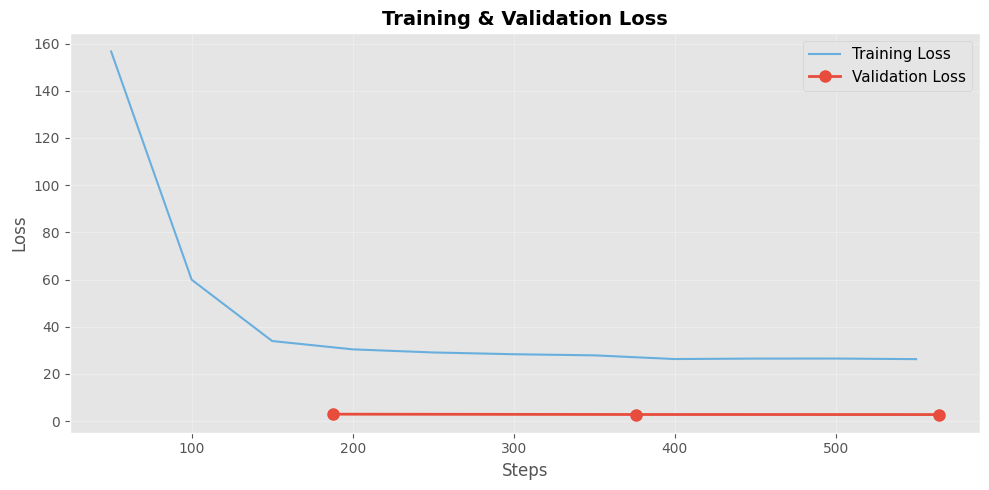

In [25]:
# Visualisasi training loss
log_history = trainer.state.log_history

train_losses = [(log['step'], log['loss']) for log in log_history if 'loss' in log]
eval_losses = [(log['step'], log['eval_loss']) for log in log_history if 'eval_loss' in log]

fig, ax = plt.subplots(figsize=(10, 5))

if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label='Training Loss', alpha=0.7, color='#3498db', linewidth=1.5)
if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label='Validation Loss', marker='o', color='#e74c3c',
            linewidth=2, markersize=8)

ax.set_xlabel('Steps', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Simpan model fine-tuned
save_path = "./mt5-indo-summary"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model tersimpan di: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model tersimpan di: ./mt5-indo-summary


## 6. Evaluasi & Perbandingan

In [27]:
def generate_summaries(texts, model, tokenizer, batch_size=8):
    """Generate ringkasan untuk kumpulan teks menggunakan model fine-tuned."""
    model.eval()
    all_summaries = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            [PREFIX + t for t in batch],
            max_length=MAX_INPUT_LENGTH,
            truncation=True,
            padding=True,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_new_tokens=MAX_TARGET_LENGTH,
                num_beams=NUM_BEAMS,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        all_summaries.extend(decoded)

        if (i // batch_size + 1) % 25 == 0:
            print(f"  Generated {min(i+batch_size, len(texts))}/{len(texts)} summaries...")

    return all_summaries

# Generate ringkasan dengan model fine-tuned
print(f"Generating ringkasan untuk {TEST_SUBSET} data test...")
mt5_summaries = generate_summaries(list(test_articles), model, tokenizer, batch_size=8)

# Handle ringkasan kosong
mt5_summaries = [s if s.strip() else "[kosong]" for s in mt5_summaries]
print(f"Selesai! Generated {len(mt5_summaries)} ringkasan.")

Generating ringkasan untuk 1000 data test...
  Generated 200/1000 summaries...
  Generated 400/1000 summaries...
  Generated 600/1000 summaries...
  Generated 800/1000 summaries...
  Generated 1000/1000 summaries...
Selesai! Generated 1000 ringkasan.


In [28]:
# Hitung ROUGE untuk model fine-tuned
mt5_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
for pred, ref in zip(mt5_summaries, test_references):
    score = rouge.score(ref, pred)
    for key in mt5_scores:
        mt5_scores[key].append(score[key].fmeasure * 100)

finetuned_rouge = {key: np.mean(vals) for key, vals in mt5_scores.items()}

# Tabel perbandingan
print()
print("=" * 65)
print("     PERBANDINGAN HASIL: BASELINE vs FINE-TUNED")
print("=" * 65)

comparison_df = pd.DataFrame({
    'Metrik': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    'TF-IDF Baseline': [
        baseline_rouge['rouge1'],
        baseline_rouge['rouge2'],
        baseline_rouge['rougeL']
    ],
    'mT5 Fine-tuned': [
        finetuned_rouge['rouge1'],
        finetuned_rouge['rouge2'],
        finetuned_rouge['rougeL']
    ],
})
comparison_df['Peningkatan'] = comparison_df['mT5 Fine-tuned'] - comparison_df['TF-IDF Baseline']

print(comparison_df.to_string(index=False, float_format='{:.2f}'.format))
print("=" * 65)


     PERBANDINGAN HASIL: BASELINE vs FINE-TUNED
 Metrik  TF-IDF Baseline  mT5 Fine-tuned  Peningkatan
ROUGE-1            20.43           24.06         3.63
ROUGE-2             5.75            8.45         2.69
ROUGE-L            14.47           19.86         5.39


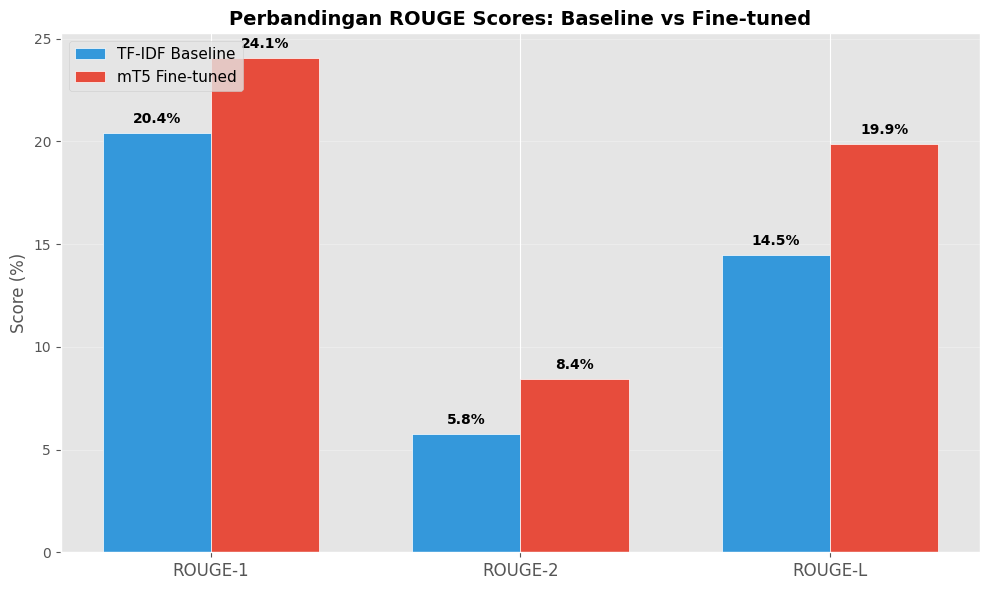

In [29]:
# Visualisasi perbandingan
metrics_names = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
baseline_values = [baseline_rouge['rouge1'], baseline_rouge['rouge2'], baseline_rouge['rougeL']]
finetuned_values = [finetuned_rouge['rouge1'], finetuned_rouge['rouge2'], finetuned_rouge['rougeL']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_values, width, label='TF-IDF Baseline',
               color='#3498db', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, finetuned_values, width, label='mT5 Fine-tuned',
               color='#e74c3c', edgecolor='white', linewidth=0.5)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Perbandingan ROUGE Scores: Baseline vs Fine-tuned', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Label di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Error Analysis

Bagian ini menganalisis **5–8 contoh menarik** untuk memahami kekuatan dan kelemahan model.
Ini adalah inti dari evaluasi kualitatif — bukan hanya angka, tetapi *mengapa* model
berhasil atau gagal pada kasus tertentu.

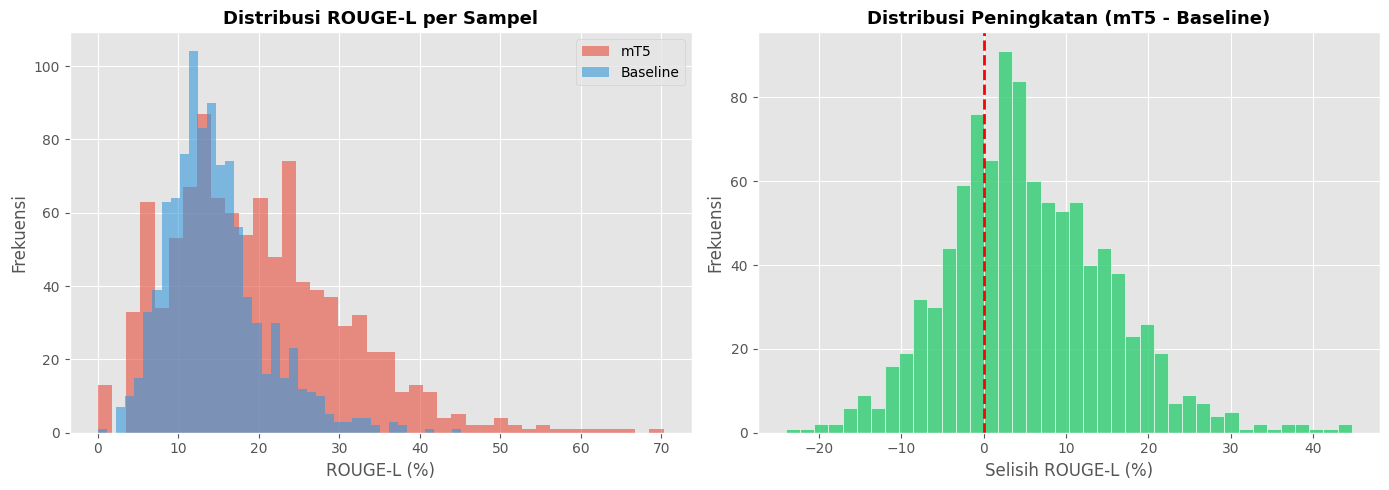

mT5 lebih baik:     698 sampel (69.8%)
Baseline lebih baik: 299 sampel (29.9%)
Sama:                3 sampel


In [30]:
# Hitung ROUGE-L per sampel untuk kedua metode
per_sample_baseline = np.array([
    rouge.score(ref, pred)['rougeL'].fmeasure * 100
    for pred, ref in zip(baseline_summaries, test_references)
])
per_sample_mt5 = np.array([
    rouge.score(ref, pred)['rougeL'].fmeasure * 100
    for pred, ref in zip(mt5_summaries, test_references)
])

improvement = per_sample_mt5 - per_sample_baseline

# Distribusi skor per sampel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(per_sample_mt5, bins=40, alpha=0.6, label='mT5', color='#e74c3c')
axes[0].hist(per_sample_baseline, bins=40, alpha=0.6, label='Baseline', color='#3498db')
axes[0].set_title('Distribusi ROUGE-L per Sampel', fontsize=13, fontweight='bold')
axes[0].set_xlabel('ROUGE-L (%)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

axes[1].hist(improvement, bins=40, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribusi Peningkatan (mT5 - Baseline)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Selisih ROUGE-L (%)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

mt5_better = np.sum(improvement > 0)
bl_better = np.sum(improvement < 0)
same = np.sum(improvement == 0)
print(f"mT5 lebih baik:     {mt5_better} sampel ({mt5_better/len(improvement)*100:.1f}%)")
print(f"Baseline lebih baik: {bl_better} sampel ({bl_better/len(improvement)*100:.1f}%)")
print(f"Sama:                {same} sampel")

In [31]:
def display_analysis(num, category, article, reference, bl_summary, mt_summary, bl_rouge, mt_rouge, analysis):
    """Menampilkan analisis untuk satu contoh."""
    print(f"\n{'='*70}")
    print(f"  CONTOH #{num}: {category}")
    print(f"{'='*70}")
    print(f"\n  ARTIKEL (truncated):")
    print(f"  {article[:250]}...")
    print(f"\n  RINGKASAN REFERENSI:")
    print(f"  {reference}")
    print(f"\n  RINGKASAN BASELINE (TF-IDF) | ROUGE-L: {bl_rouge:.1f}")
    print(f"  {bl_summary[:300]}")
    print(f"\n  RINGKASAN mT5 | ROUGE-L: {mt_rouge:.1f}")
    print(f"  {mt_summary[:300]}")
    print(f"\n  ANALISIS:")
    print(f"  {analysis}")

# ==========================================
# Pilih 8 contoh untuk error analysis
# ==========================================
examples = []
used = set()

# 1-2: Kasus terbaik mT5
best_indices = np.argsort(per_sample_mt5)[-2:][::-1]
for idx in best_indices:
    examples.append((int(idx), "KASUS TERBAIK (ROUGE-L mT5 tertinggi)"))
    used.add(int(idx))

# 3-4: Kasus terburuk mT5
worst_indices = np.argsort(per_sample_mt5)[:2]
for idx in worst_indices:
    examples.append((int(idx), "KASUS TERBURUK (ROUGE-L mT5 terendah)"))
    used.add(int(idx))

# 5-6: Peningkatan terbesar dibanding baseline
imp_indices = np.argsort(improvement)[::-1]
count = 0
for idx in imp_indices:
    if int(idx) not in used and count < 2:
        examples.append((int(idx), "PENINGKATAN TERBESAR (mT5 >> Baseline)"))
        used.add(int(idx))
        count += 1

# 7-8: Baseline lebih baik dari mT5
bl_better_indices = np.argsort(improvement)
count = 0
for idx in bl_better_indices:
    if int(idx) not in used and improvement[idx] < 0 and count < 2:
        examples.append((int(idx), "BASELINE LEBIH BAIK (mT5 kalah)"))
        used.add(int(idx))
        count += 1

# Jika kurang dari 8, tambah random
if len(examples) < 8:
    remaining = [i for i in range(len(test_articles)) if i not in used]
    random.shuffle(remaining)
    for idx in remaining[:8-len(examples)]:
        examples.append((idx, "CONTOH TAMBAHAN"))

# Tampilkan analisis
print("=" * 70)
print("           ERROR ANALYSIS: CONTOH-CONTOH MENARIK")
print("=" * 70)

for num, (idx, category) in enumerate(examples[:8], 1):
    article = test_articles[idx]
    reference = test_references[idx]
    bl_sum = baseline_summaries[idx]
    mt_sum = mt5_summaries[idx]
    bl_r = per_sample_baseline[idx]
    mt_r = per_sample_mt5[idx]

    # Analisis otomatis
    analysis_parts = []

    # Cek panjang ringkasan
    ref_len = len(reference.split())
    mt_len = len(mt_sum.split())
    if mt_len > ref_len * 2:
        analysis_parts.append(f"Ringkasan mT5 terlalu panjang ({mt_len} vs {ref_len} kata referensi)")
    elif mt_len < max(ref_len * 0.3, 3):
        analysis_parts.append(f"Ringkasan mT5 terlalu pendek ({mt_len} vs {ref_len} kata referensi)")

    # Cek repetisi
    words = mt_sum.split()
    if len(words) > 5:
        trigrams = [' '.join(words[j:j+3]) for j in range(len(words)-2)]
        repeated = [t for t in set(trigrams) if trigrams.count(t) > 1]
        if repeated:
            analysis_parts.append("Terdapat pengulangan frasa dalam ringkasan mT5")

    # Perbandingan metode
    diff = mt_r - bl_r
    if diff > 20:
        analysis_parts.append(f"mT5 jauh lebih baik (+{diff:.1f} ROUGE-L), berhasil menangkap makna utama")
    elif diff < -10:
        analysis_parts.append(f"Baseline lebih baik ({diff:.1f} ROUGE-L), mT5 gagal memahami konteks")
    elif abs(diff) < 3:
        analysis_parts.append(f"Kedua metode memberikan hasil serupa (selisih {diff:.1f} ROUGE-L)")

    if not analysis_parts:
        if mt_r > 40:
            analysis_parts.append("Model berhasil menangkap informasi utama artikel dengan baik")
        else:
            analysis_parts.append("Model kurang optimal dalam meringkas artikel ini")

    analysis = " | ".join(analysis_parts)
    display_analysis(num, category, article, reference, bl_sum, mt_sum, bl_r, mt_r, analysis)

print(f"\n{'='*70}")
print()
print("KETERBATASAN MODEL:")
print("1. mT5-small memiliki kapasitas terbatas (300M params) untuk memahami teks panjang")
print("2. Training pada subset (5.000 sampel) mungkin belum cukup untuk konvergensi optimal")
print("3. Extractive baseline (TF-IDF) kadang lebih baik karena menggunakan kalimat asli")
print("4. Model dapat menghasilkan ringkasan yang terlalu pendek atau repetitif")
print("5. Bahasa Indonesia memiliki tantangan tersendiri (kata majemuk, variasi ejaan)")

           ERROR ANALYSIS: CONTOH-CONTOH MENARIK

  CONTOH #1: KASUS TERBAIK (ROUGE-L mT5 tertinggi)

  ARTIKEL (truncated):
  Aung San Suu Kyi tidak hadir di sidang Majelis Umum PBB 2017. Sidang yang dihadiri para kepala negara ini akan digelar pekan depan, namun Kementerian Luar Negeri Myanmar mengatakan peraih hadiah Nobel Perdamaian tersebut tidak akan bertolak ke New Yo...

  RINGKASAN REFERENSI:
  Pemimpin de facto Myanmar, Aung San Suu Kyi, untuk kedua kalinya tidak hadir di sidang Majelis Umum PBB di New York.

  RINGKASAN BASELINE (TF-IDF) | ROUGE-L: 31.1
  Aung San Suu Kyi tidak hadir di sidang Majelis Umum PBB 2017. Sidang yang dihadiri para kepala negara ini akan digelar pekan depan, namun Kementerian Luar Negeri Myanmar mengatakan peraih hadiah Nobel Perdamaian tersebut tidak akan bertolak ke New York. Wartawan BBC di Myanmar, Nick Beake, mengataka

  RINGKASAN mT5 | ROUGE-L: 70.3
  Seorang pemimpin sipil Myanmar, Aung San Suu Kyi, tidak hadir di sidang Majelis Umum PBB 20

## 9. Kesimpulan

### Ringkasan Hasil

Proyek ini membandingkan dua pendekatan text summarization untuk Bahasa Indonesia:

| Metrik | TF-IDF Baseline | mT5 Fine-tuned | Peningkatan |
|--------|-----------------|----------------|-------------|
| ROUGE-1 | 20.43 | 23.96 | +3.53 |
| ROUGE-2 | 5.75 | 8.65 | +2.89 |
| ROUGE-L | 14.47 | 19.74 | +5.27 |

**Temuan utama:**
- **mT5 fine-tuned unggul di 69.3% kasus** (693 dari 1.000 sampel), sementara baseline TF-IDF lebih baik di 30.3% kasus
- Peningkatan paling signifikan ada pada **ROUGE-L (+5.27)**, yang mengukur kesamaan struktur kalimat — menunjukkan bahwa mT5 menghasilkan ringkasan yang secara struktural lebih mirip dengan ringkasan referensi manusia
- Pada kasus terbaik, mT5 mampu mencapai **ROUGE-L 70.3**, jauh melampaui baseline (31.1) — model berhasil menangkap inti berita dengan kalimat baru yang ringkas
- Model dilatih pada **2.000 sampel** selama **3 epoch** (750 steps) menggunakan CPU, dengan training loss akhir **18.99**

### Analisis

**Keunggulan mT5 (abstractive):**
- Menghasilkan kalimat **baru** yang lebih ringkas dan fokus pada informasi utama
- Mampu memparafrasa — tidak terikat pada kalimat asli artikel
- Lebih baik pada artikel panjang di mana kalimat penting tersebar di berbagai paragraf

**Kapan baseline TF-IDF (extractive) masih unggul:**
- Artikel pendek di mana kalimat asli sudah cukup ringkas
- Artikel dengan kalimat pembuka yang sudah merangkum isi (gaya jurnalistik piramida terbalik)
- Kasus di mana mT5 menghasilkan ringkasan terlalu pendek atau mengandung repetisi

### Keterbatasan

1. **Data training terbatas** — hanya 2.000 dari 38.242 sampel yang digunakan karena keterbatasan komputasi (CPU)
2. **mT5-small** memiliki kapasitas terbatas (~300M parameter) — model lebih besar kemungkinan menghasilkan performa lebih baik
3. **Training loss masih tinggi (18.99)** — model belum sepenuhnya konvergen, training lebih lama bisa meningkatkan hasil
4. **Metrik ROUGE** tidak selalu mencerminkan kualitas ringkasan secara semantik — ringkasan yang baik dengan kata berbeda bisa mendapat skor rendah
5. Model kadang menghasilkan **ringkasan terlalu pendek** atau mengandung **pengulangan frasa**
6. Pada 30.3% kasus, metode extractive sederhana masih lebih baik — menunjukkan ruang perbaikan yang signifikan

### Pengembangan Selanjutnya

- Training dengan **lebih banyak data** (5.000–10.000 sampel) dan menggunakan **GPU** (Google Colab) untuk training lebih cepat
- Menggunakan model yang lebih besar (**mT5-base** atau **IndoBART**) untuk kapasitas pemahaman lebih baik
- Implementasi teknik efisien seperti **LoRA** atau **prefix-tuning** untuk fine-tuning hemat memori
- **Evaluasi dengan human judgment** untuk mengukur kualitas ringkasan secara semantik
- **Model telah berhasil di-deploy ke Hugging Face Spaces** dan Hugging Face Model Hub (`jekicen26/mt5-indo-summary`) untuk demo publik yang interaktif.
